### ============================================================================
### 02_METRICS.IPYNB — Проверка гипотез и расчёт метрик
### ============================================================================

In [9]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ Библиотеки импортированы")

✅ Библиотеки импортированы


In [10]:
CLEANED_DATA_PATH = Path(r"C:\Users\User\Documents\MyPetProjects\fintech-case\data\processed")

# Загружаем уже очищенные данные
df = pd.read_csv(CLEANED_DATA_PATH / "customers_clean.csv")
print(f"✅ Загружены очищенные данные: {len(df)} записей")

✅ Загружены очищенные данные: 10000 записей


##### ============================================================================
##### Гипотеза 1 — «U-образная кривая оттока по tenure: новые и «ветераны» уходят чаще»
##### ============================================================================

Риск ухода клиента (churn risk) максимален в двух противоположных точках: сразу после открытия счета и спустя много лет обслуживания. Клиенты «среднего возраста» (tenure 3–7 лет), напротив, являются самым стабильным ядром базы.
- Факторы Early Churn (длительность отношений < 1 года): слабый онбординг, охота за бонусами, низкие барьеры выхода.
- Факторы Late Churn (длительность отношений > 10 лет): эффект "забытого клиента", изменение жизненных обстоятельств, технологическое отставание по сравнению с необанками.
- Клиенты со стажем 2–7 лет - ядро, в «зоне комфорта»: привыкли к интерфейсу, накопили бонусы лояльности и, возможно, используют банк как основной (зарплата, кредиты).

In [11]:
# Создаём группы тенура на основе бизнес-логики:
# • 0-1 год: "Новички" — период адаптации, высокий риск ухода
# • 2-7 лет: "Стабильные" — основная лояльная база
# • 8+ лет: "Ветераны" — риск "усталости" от продукта или переманивания, могут искать альтернативы

df['tenure_group'] = pd.cut(
    df['tenure'], 
    bins=[-1, 1, 7, 100],  # -1 чтобы включить 0; 100 чтобы захватить всё до конца
    labels=['0-1 год', '2-7 лет', '8+ лет'],
    right=True,
)

# Проверяем, как распределились клиенты по группам
print("📊 Распределение клиентов по группам длительности отношений:")
print(df['tenure_group'].value_counts().sort_index())

📊 Распределение клиентов по группам длительности отношений:
tenure_group
0-1 год    1448
2-7 лет    6053
8+ лет     2499
Name: count, dtype: int64


In [12]:
churn_by_tenure = (
    df.groupby('tenure_group', observed=True, as_index=False)['churn']
    .agg([
        ('clients_cnt', 'count'),     # Сколько всего клиентов в группе
        ('churned_cnt', 'sum'),       # Сколько ушло (т.к. churn = 0/1, сумма = количество единиц)
        ('churn_rate', 'mean')        # Среднее = доля ушедших
    ])
    .assign(
        churn_rate_pct=lambda x: x['churn_rate'] * 100
    )
    .round(2)
)

print("\n📈 Churn Rate по группам длительности отношений:")
print(churn_by_tenure[['clients_cnt', 'churned_cnt', 'churn_rate_pct']])


📈 Churn Rate по группам длительности отношений:
   clients_cnt  churned_cnt  churn_rate_pct
0         1448          327           22.58
1         6053         1199           19.81
2         2499          511           20.45



📈 Churn Rate по группам длительности отношений:
  tenure_group  clients_cnt  churned_cnt  churn_rate  churn_rate_pct
0      0-1 год         1448          327        0.23           22.58
1      2-7 лет         6053         1199        0.20           19.81
2       8+ лет         2499          511        0.20           20.45


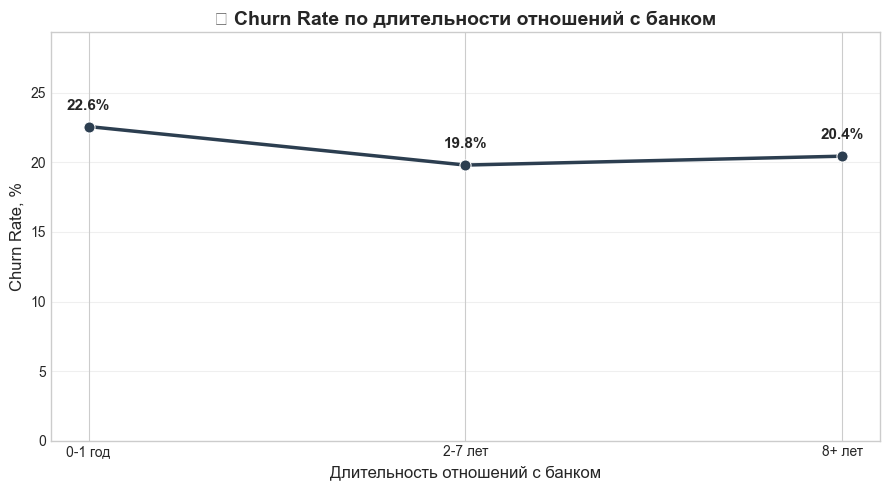

In [13]:
# Считаем метрики по группам
churn_by_tenure = (
    df.groupby('tenure_group', observed=True, as_index=False)['churn']
    .agg([
        ('clients_cnt', 'count'),     # Сколько всего клиентов в группе
        ('churned_cnt', 'sum'),       # Сколько ушло (т.к. churn = 0/1, сумма = количество единиц)
        ('churn_rate', 'mean')        # Среднее = доля ушедших
    ])
    .assign(
        churn_rate_pct=lambda x: x['churn_rate'] * 100
    )
    .round(2)
)

print("\n📈 Churn Rate по группам длительности отношений:")
print(churn_by_tenure)

# Визуализация: линейный график для демонстрации U-формы
plt.figure(figsize=(9, 5))
ax = sns.lineplot(
    data=churn_by_tenure,
    x='tenure_group', 
    y='churn_rate_pct',
    marker='o',
    linewidth=2.5,
    markersize=8,
    color='#2c3e50'
)

# Добавляем подписи значений над точками
for i, (idx, row) in enumerate(churn_by_tenure.iterrows()):
    plt.text(
        i, row['churn_rate_pct'] + 1,  # +1 чтобы текст не наезжал на точку
        f"{row['churn_rate_pct']:.1f}%", 
        ha='center', va='bottom', 
        fontsize=11, fontweight='bold'
    )

# Оформление
plt.title('📉 Churn Rate по длительности отношений с банком', fontweight='bold', fontsize=14)
plt.xlabel('Длительность отношений с банком', fontsize=12)
plt.ylabel('Churn Rate, %', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, max(churn_by_tenure['churn_rate_pct']) * 1.3)  # Запас сверху для подписей

plt.tight_layout()
plt.show()

In [14]:
# ============================================================================
# СТАТИСТИЧЕСКИЙ ТЕСТ: Хи-квадрат для проверки связи "Длительность отношений ↔ churn"
# ============================================================================

# Создаём таблицу сопряжённости: группы длительности отношений × факт оттока
cont_table = pd.crosstab(df['tenure_group'], df['churn'])
print("📋 Таблица сопряжённости (строки = группы, столбцы = churn):")
print(cont_table)

# Проводим тест хи-квадрат
chi2_stat, p_value, dof, expected = stats.chi2_contingency(cont_table)

print(f"\n📊 Результаты χ²-теста:")
print(f"   Хи-квадрат статистика: {chi2_stat:.3f}")
print(f"   Степени свободы (dof): {dof}")
print(f"   p-value: {p_value:.4f}")

# Интерпретация
alpha = 0.05
if p_value < alpha:
    print(f"\n✅ СТАТИСТИЧЕСКИ ЗНАЧИМО (p < {alpha})")
    print("   → Есть связь между длительностью отношений и оттоком")
    print("   → Гипотеза о различиях между группами ПОДТВЕРЖДЕНА")
else:
    print(f"\n❌ НЕ ЗНАЧИМО (p >= {alpha})")
    print("   → Различия в оттоке между группами могут быть случайными")
    print("   → Гипотеза НЕ подтверждена статистически")


# Считаем стандартную ошибку и 95% ДИ для каждой группы
churn_by_tenure['std_error'] = np.sqrt(
    churn_by_tenure['churn_rate'] * (1 - churn_by_tenure['churn_rate']) / churn_by_tenure['clients_cnt']
)
churn_by_tenure['ci_lower'] = (churn_by_tenure['churn_rate'] - 1.96 * churn_by_tenure['std_error']) * 100
churn_by_tenure['ci_upper'] = (churn_by_tenure['churn_rate'] + 1.96 * churn_by_tenure['std_error']) * 100

# Вывод ДИ в текстовом виде
print("\n📊 Churn Rate с 95% доверительными интервалами:")
for idx, row in churn_by_tenure.iterrows():
    print(f"{row['tenure_group']}: {row['churn_rate_pct']:5.1f}% [{row['ci_lower']:.1f}% – {row['ci_upper']:.1f}%]")

📋 Таблица сопряжённости (строки = группы, столбцы = churn):
churn            0     1
tenure_group            
0-1 год       1121   327
2-7 лет       4854  1199
8+ лет        1988   511

📊 Результаты χ²-теста:
   Хи-квадрат статистика: 5.558
   Степени свободы (dof): 2
   p-value: 0.0621

❌ НЕ ЗНАЧИМО (p >= 0.05)
   → Различия в оттоке между группами могут быть случайными
   → Гипотеза НЕ подтверждена статистически

📊 Churn Rate с 95% доверительными интервалами:
0-1 год:  22.6% [20.8% – 25.2%]
2-7 лет:  19.8% [19.0% – 21.0%]
8+ лет:  20.4% [18.4% – 21.6%]


Гипотеза не подтвердилась, что тоже ценный результат. Следует проверять другие переменные для исследования эффекта.

##### ============================================================================
##### Гипотеза 2 — «Клиенты 46–60 лет уходят чаще»
##### ============================================================================

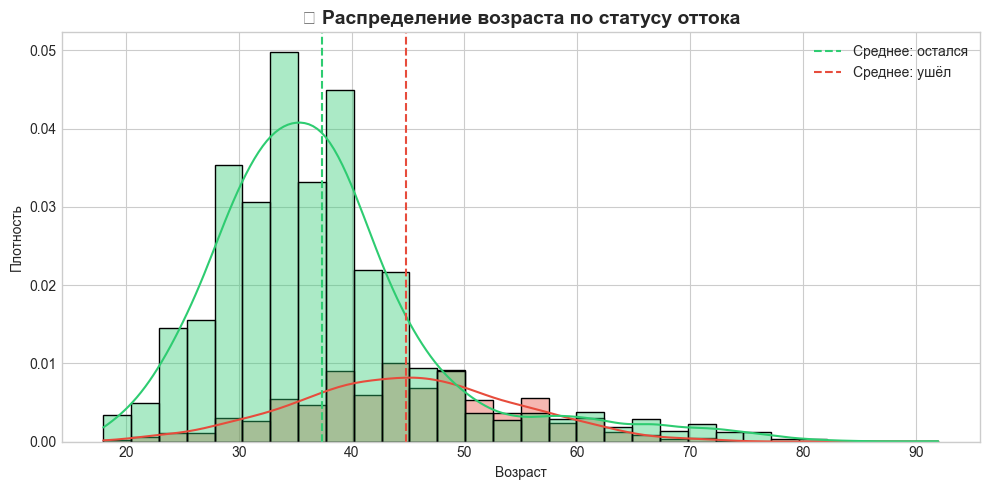


📈 Средний age:
   • Остался: 37.4
   • Ушёл:    44.8
   • Разница: -7.4 пунктов


In [15]:
# График: распределение age для ушедших и оставшихся
plt.figure(figsize=(10, 5))

# Используем sns.histplot с hue для разделения по группам
sns.histplot(
    data=df,
    x='age',
    hue='churn',
    bins=30,
    kde=True,
    alpha=0.4,
    palette=['#2ecc71', '#e74c3c'],
    stat='density'  # нормируем, чтобы сравнивать формы распределений
)

plt.title('📊 Распределение возраста по статусу оттока', fontweight='bold', fontsize=14)
plt.xlabel('Возраст')
plt.ylabel('Плотность')
plt.legend(['Остался (0)', 'Ушёл (1)'], title='Churn')
plt.axvline(df[df['churn']==0]['age'].mean(), color='#2ecc71', linestyle='--', linewidth=1.5, label='Среднее: остался')
plt.axvline(df[df['churn']==1]['age'].mean(), color='#e74c3c', linestyle='--', linewidth=1.5, label='Среднее: ушёл')
plt.legend()
plt.tight_layout()
plt.show()

# Вывод средних значений
mean_stayed = df[df['churn'] == 0]['age'].mean()
mean_churned = df[df['churn'] == 1]['age'].mean()
print(f"\n📈 Средний age:")
print(f"   • Остался: {mean_stayed:.1f}")
print(f"   • Ушёл:    {mean_churned:.1f}")
print(f"   • Разница: {mean_stayed - mean_churned:.1f} пунктов")

In [16]:
# t-test — есть ли разница в средних?

score_stayed = df[df['churn'] == 0]['age']
score_churned = df[df['churn'] == 1]['age']

# Проводим t-тест
t_stat, p_value = stats.ttest_ind(score_stayed, score_churned, equal_var=False)

print("📊 t-test:")
print(f"   t-statistic: {t_stat:.3f}")
print(f"   p-value:     {p_value:.4f}")
print(f"   Среднее (остался):  {score_stayed.mean():.1f} ± {score_stayed.std():.1f}")
print(f"   Среднее (ушёл):     {score_churned.mean():.1f} ± {score_churned.std():.1f}")

# Эффект размера: Cohen's d (насколько велика разница на практике)
pooled_std = np.sqrt(((len(score_stayed)-1)*score_stayed.var() + (len(score_churned)-1)*score_churned.var()) / 
                     (len(score_stayed) + len(score_churned) - 2))
cohens_d = (score_stayed.mean() - score_churned.mean()) / pooled_std

print(f"\n📏 Размер эффекта (Cohen's d): {abs(cohens_d):.3f}")
print("   Интерпретация: <0.2 — малый, 0.2–0.5 — средний, >0.5 — большой")

# Интерпретация
if p_value < 0.05:
    print(f"\n✅ Разница СТАТИСТИЧЕСКИ ЗНАЧИМА (p < 0.05)")
else:
    print(f"\n❌ Разница НЕ значима (p >= 0.05)")

if abs(cohens_d) < 0.2:
    print(f"❌ Эффект МАЛЫЙ")
elif abs(cohens_d) > 0.5:
    print(f"✅ Эффект БОЛЬШОЙ")
else:
    print(f" Эффект СРЕДНИЙ")

# 1. Не линейна ли связь? Может, риск растёт только после 50?
df['age_group'] = pd.cut(df['age'], bins=[18, 30, 45, 60, 100], 
                          labels=['18-30', '31-45', '46-60', '60+'])
churn_by_age_group = df.groupby('age_group', observed=True)['churn'].mean() * 100
print(f"\n{churn_by_age_group.round(2)}")

# Есть ли взаимодействие возраст × активность?
pivot = pd.pivot_table(df, values='churn', index='active_member', 
                       columns=pd.cut(df['age'], [18,45,100], labels=['<45','45+']), 
                       aggfunc='mean') * 100
print(f"\n{pivot.round(2)}")

📊 t-test:
   t-statistic: -30.419
   p-value:     0.0000
   Среднее (остался):  37.4 ± 10.1
   Среднее (ушёл):     44.8 ± 9.8

📏 Размер эффекта (Cohen's d): 0.739
   Интерпретация: <0.2 — малый, 0.2–0.5 — средний, >0.5 — большой

✅ Разница СТАТИСТИЧЕСКИ ЗНАЧИМА (p < 0.05)
✅ Эффект БОЛЬШОЙ

age_group
18-30     7.50
31-45    15.74
46-60    51.12
60+      24.78
Name: churn, dtype: float64

age              <45    45+
active_member              
0              17.43  69.75
1               9.92  28.02


### 💼 Бизнес-рекомендации на основе инсайтов

#### 🎯 Приоритет 1: Сегмент «46–60 лет + неактивен» (69.7% churn):
Действия:
- Триггер: 30 дней неактивности → персональный контакт
- Канал: телефон / email, а не только мобильное приложение

#### 🎯 Приоритет 2: Онбординг для 45+
Действия:
- Упрощённый интерфейс
- Видео-гайд «Первые 5 минут в приложении»